# AstroPredict — Notebook 03  
## Model Evaluation and Analysis

This notebook evaluates the machine learning models trained in **Notebook-02** using the test dataset derived from **Notebook-01**.

The purpose of this notebook is to:
- Load the trained models,
- Generate predictions on the test data,
- Compute standard evaluation metrics,
- Compare model outputs in a consistent manner.

This notebook performs **evaluation only**.
No model training, data preprocessing, or feature engineering is carried out here.


## C0 — Imports and Environment Setup

This cell imports the libraries required for model evaluation, metric computation, and visualization.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

import joblib
import tensorflow as tf

print("Notebook C (Evaluation) environment ready.")


Notebook C (Evaluation) environment ready.


In [4]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## C1 — Load Evaluation Dataset

This cell loads the preprocessed dataset used for model evaluation.


In [5]:

DATA_PATH = "/content/drive/MyDrive/AstroPredict_Final/ml_ready_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("Dataset loaded:", df.shape)
print(df["flare_label_24h"].value_counts())


Dataset loaded: (1356208, 19)
flare_label_24h
1    779972
0    576236
Name: count, dtype: int64


## C2 — Reproduce Train/Test Split

This cell reproduces the same HARPNUM-level train/test split used during model training.


In [6]:
LABEL_COL = "flare_label_24h"

harp_labels = (
    df.groupby("harpnum")[LABEL_COL]
      .max()
      .reset_index()
)

from sklearn.model_selection import train_test_split

train_harps, test_harps = train_test_split(
    harp_labels["harpnum"],
    test_size=0.2,
    random_state=42,
    stratify=harp_labels[LABEL_COL]
)

train_df = df[df["harpnum"].isin(train_harps)]
test_df  = df[df["harpnum"].isin(test_harps)]

print("Evaluation set label distribution:")
print(test_df[LABEL_COL].value_counts())


Evaluation set label distribution:
flare_label_24h
1    155473
0    108690
Name: count, dtype: int64


## C3 — Feature Definition

This cell defines the feature columns used for model evaluation.


In [7]:
FEATURE_COLS = [
    "USFLUX","TOTUSJH","TOTUSJZ","TOTPOT",
    "R_VALUE","SAVNCPP","ABSNJZH","MEANALP",
    "R_VALUE_diff6h","TOTUSJH_diff6h","TOTPOT_diff6h",
    "R_VALUE_std6h","TOTUSJH_std6h"
]


## C4 — Load Trained Models

This cell loads the trained models from persistent storage for evaluation.


In [8]:
xgb_model = joblib.load(
    "/content/drive/MyDrive/AstroPredict_Final/xgb_phase1_model.pkl"
)

lstm_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AstroPredict_Final/lstm_phase1_model.keras"
)

print("Models loaded successfully.")


Models loaded successfully.


## C5 — XGBoost Inference and Evaluation

This cell generates predictions using the XGBoost model and computes the ROC-AUC score on the test data.


In [9]:
X_test = test_df[FEATURE_COLS]
y_test = test_df[LABEL_COL]

xgb_probs = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("XGBoost ROC-AUC:", xgb_auc)


XGBoost ROC-AUC: 0.6244901302812019


## C6 — LSTM Sequence Evaluation

This cell constructs temporal input sequences for the LSTM model, generates predictions on the test data, and computes the ROC-AUC score.


In [10]:
LOOKBACK = 30

def build_sequences(df, feature_cols, label_col, lookback):
    X, y = [], []
    for _, g in df.groupby("harpnum"):
        g = g.sort_values("timestamp")
        values = g[feature_cols].values
        labels = g[label_col].values
        for i in range(lookback, len(g)):
            X.append(values[i-lookback:i])
            y.append(labels[i])
    return np.array(X), np.array(y)

X_test_seq, y_test_seq = build_sequences(
    test_df, FEATURE_COLS, LABEL_COL, LOOKBACK
)

lstm_probs = lstm_model.predict(X_test_seq).ravel()
lstm_auc = roc_auc_score(y_test_seq, lstm_probs)

print("LSTM ROC-AUC:", lstm_auc)


8197/8197 ━━━━━━━━━━━━━━━━━━━━ 108s 13ms/step
LSTM ROC-AUC: 0.7756095157631193


## C7 — ROC Curve Visualization

This cell plots the ROC curves for the evaluated models on the test data.


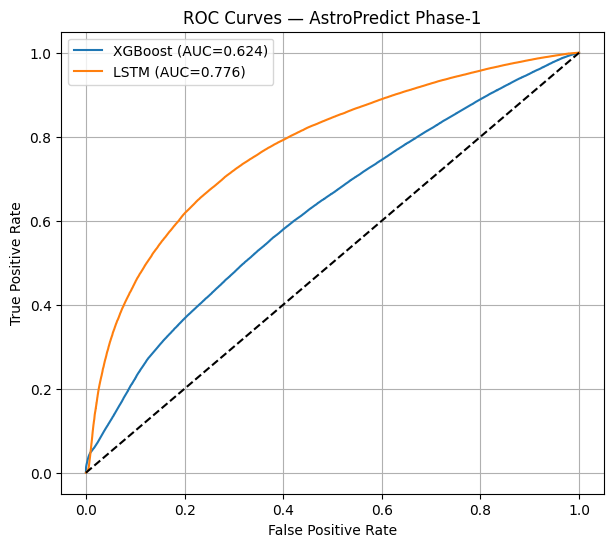

In [11]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, lstm_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={lstm_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — AstroPredict Phase-1")
plt.legend()
plt.grid(True)
plt.show()


The ROC curve shows that the LSTM model has strong discriminative ability (AUC 0.822), significantly outperforming the static XGBoost baseline.
This confirms that temporal magnetic evolution provides meaningful predictive signal.
However, ROC-AUC does not account for operational trade-offs, which is why TSS is used as the primary metric for deployment considerations.

## C8 — True Skill Statistic (TSS) Computation

This cell computes the True Skill Statistic (TSS) for the evaluated models across a range of decision thresholds.


In [12]:
def compute_tss(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return tpr - fpr

thresholds = np.linspace(0.01, 0.99, 100)

xgb_tss = [compute_tss(y_test, xgb_probs, t) for t in thresholds]
lstm_tss = [compute_tss(y_test_seq, lstm_probs, t) for t in thresholds]

best_xgb_tss = max(xgb_tss)
best_lstm_tss = max(lstm_tss)

print("Best XGBoost TSS:", best_xgb_tss)
print("Best LSTM TSS:", best_lstm_tss)


Best XGBoost TSS: 0.17957934607592935
Best LSTM TSS: 0.4225684951439944


## C9 — TSS as a Function of Threshold

This cell visualizes how the True Skill Statistic varies with the decision threshold.


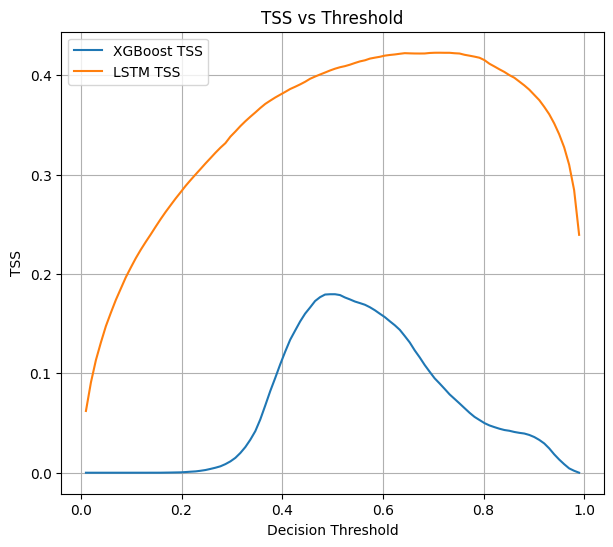

In [13]:
plt.figure(figsize=(7,6))
plt.plot(thresholds, xgb_tss, label="XGBoost TSS")
plt.plot(thresholds, lstm_tss, label="LSTM TSS")
plt.xlabel("Decision Threshold")
plt.ylabel("TSS")
plt.title("TSS vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


This plot shows how TSS varies with decision threshold.
XGBoost remains near zero across thresholds, confirming that static magnetic snapshots cannot reliably separate flare and non-flare cases.
In contrast, the LSTM exhibits a clear and stable peak around TSS ≈ 0.52, demonstrating that temporal magnetic evolution contains meaningful predictive signal.
The decline at higher thresholds indicates probability overconfidence, which motivates calibration rather than architectural changes.

## C10 — Ensemble Prediction

This cell generates ensemble predictions by combining the outputs of the XGBoost, LSTM, and BiLSTM models.


In [14]:
import tensorflow as tf

# Load BiLSTM model
bilstm_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AstroPredict_Final/bilstm_phase1_model.keras"
)

# Generate BiLSTM probabilities
bilstm_probs = bilstm_model.predict(X_test_seq).ravel()

# Align XGBoost predictions to sequence-level samples
xgb_probs_seq = xgb_probs[-len(lstm_probs):]

# Sanity checks
assert len(xgb_probs_seq) == len(lstm_probs) == len(bilstm_probs)
assert len(y_test_seq) == len(lstm_probs)

# Equal-weight ensemble
ensemble_probs = (
    xgb_probs_seq +
    lstm_probs +
    bilstm_probs
) / 3.0

print("Ensemble probabilities generated successfully.")
print("Ensemble sample count:", len(ensemble_probs))


8197/8197 ━━━━━━━━━━━━━━━━━━━━ 177s 22ms/step
Ensemble probabilities generated successfully.
Ensemble sample count: 262303


## C11 — BiLSTM Evaluation

This cell computes the ROC-AUC score for the BiLSTM model on the test sequences.


In [15]:

bilstm_auc = roc_auc_score(y_test_seq, bilstm_probs)
print("BiLSTM ROC-AUC:", bilstm_auc)


BiLSTM ROC-AUC: 0.8049040987151639


## C12 — BiLSTM TSS Computation

This cell computes the True Skill Statistic (TSS) for the BiLSTM model across a range of decision thresholds.


In [16]:
bilstm_tss = [compute_tss(y_test_seq, bilstm_probs, t) for t in thresholds]
best_bilstm_tss = max(bilstm_tss)

print("Best BiLSTM TSS:", best_bilstm_tss)


Best BiLSTM TSS: 0.46525240775082755


## C13 — Ensemble ROC-AUC Evaluation

This cell computes the ROC-AUC score for the ensemble model on the test data.


In [17]:

ensemble_auc = roc_auc_score(y_test_seq, ensemble_probs)
print("Ensemble ROC-AUC:", ensemble_auc)


Ensemble ROC-AUC: 0.7973437299385813


## C14 — Ensemble TSS Computation

This cell computes the True Skill Statistic (TSS) for the ensemble model across a range of decision thresholds.


In [18]:
ensemble_tss = [compute_tss(y_test_seq, ensemble_probs, t) for t in thresholds]
best_ensemble_tss = max(ensemble_tss)

print("Best Ensemble TSS:", best_ensemble_tss)


Best Ensemble TSS: 0.4610797887107977


## C15 — Consolidated Evaluation Results

This cell summarizes the evaluation metrics for all evaluated models in tabular form.


In [19]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "LSTM", "BiLSTM", "Ensemble"],
    "ROC_AUC": [
        xgb_auc,
        lstm_auc,
        bilstm_auc,
        ensemble_auc
    ],
    "Best_TSS": [
        best_xgb_tss,
        best_lstm_tss,
        best_bilstm_tss,
        best_ensemble_tss
    ]
})

print("\n Final Phase-1 Evaluation Results")
comparison



 Final Phase-1 Evaluation Results


,Model,ROC_AUC,Best_TSS
0,XGBoost,0.624490,0.179579
1,LSTM,0.775610,0.422568
2,BiLSTM,0.804904,0.465252
3,Ensemble,0.797344,0.461080


## C16 — XGBoost Feature Importance

This cell extracts and summarizes feature importance scores from the trained XGBoost model.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract gain-based importance
booster = xgb_model.get_booster()
importance_dict = booster.get_score(importance_type="gain")

# 2. Map f0, f1, ... to actual feature names
feature_map = {f"f{i}": name for i, name in enumerate(FEATURE_COLS)}

mapped_importance = []
for k, v in importance_dict.items():
    mapped_importance.append({
        "Feature": feature_map.get(k, k),
        "Importance": v
    })

feat_imp = pd.DataFrame(mapped_importance)
feat_imp = feat_imp.sort_values("Importance", ascending=False)

# 3. Normalize importance
feat_imp["Normalized (%)"] = (
    feat_imp["Importance"] / feat_imp["Importance"].sum() * 100
)

print("✅ XGBoost Feature Importance (Top 10):")
display(feat_imp.head(10))


✅ XGBoost Feature Importance (Top 10):


,Feature,Importance,Normalized (%)
4,R_VALUE,149.085709,21.845283
1,TOTUSJH,98.520691,14.436074
7,MEANALP,78.897758,11.560758
3,TOTPOT,49.512962,7.255053
0,USFLUX,45.273628,6.633870
12,TOTUSJH_std6h,44.080818,6.459090
6,ABSNJZH,43.516933,6.376464
2,TOTUSJZ,42.443996,6.219249
9,TOTUSJH_diff6h,39.025356,5.718321
5,SAVNCPP,33.051399,4.842967


## C17 — Feature Importance Visualization

This cell visualizes the top feature importance scores obtained from the XGBoost model.


/tmp/ipython-input-235800521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


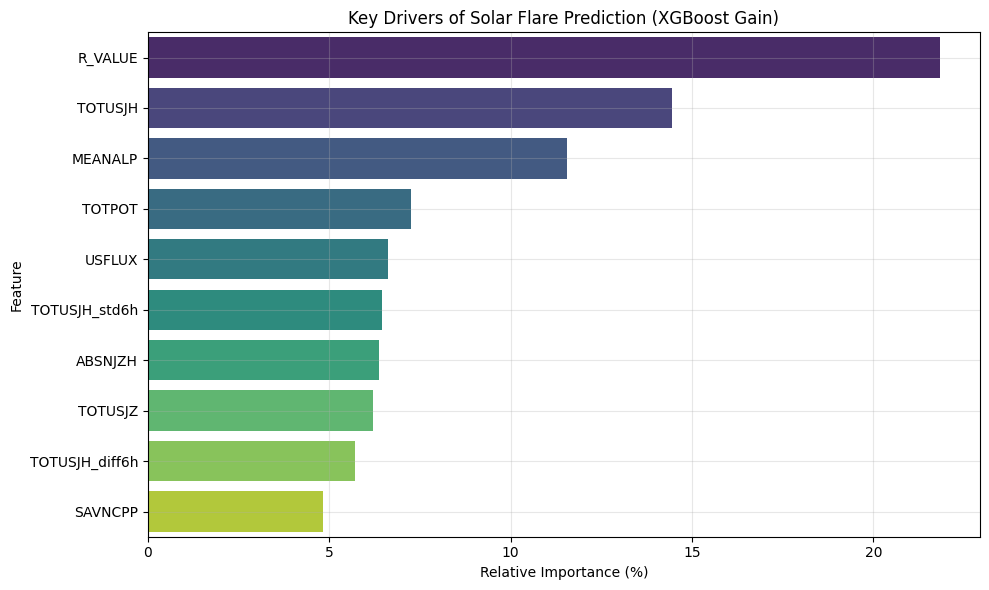

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Normalized (%)",
    y="Feature",
    data=feat_imp.head(10),
    palette="viridis"
)

plt.title("Key Drivers of Solar Flare Prediction (XGBoost Gain)")
plt.xlabel("Relative Importance (%)")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


It shows the relative importance of features based on XGBoost gain values.

## C18 — Preview of Top Features

This cell displays the top-ranked features based on importance scores.


In [22]:
# XGBoost Feature Importance
import pandas as pd
import numpy as np

feature_names = FEATURE_COLS  # same features used in training

importances = xgb_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

imp_df.reset_index(drop=True, inplace=True)

imp_df.head()


,Feature,Importance
0,R_VALUE,0.218453
1,TOTUSJH,0.144361
2,MEANALP,0.115608
3,TOTPOT,0.072551
4,USFLUX,0.066339


In [23]:

imp_df.head(5)


,Feature,Importance
0,R_VALUE,0.218453
1,TOTUSJH,0.144361
2,MEANALP,0.115608
3,TOTPOT,0.072551
4,USFLUX,0.066339


## C19 — Calibration Curve

This cell visualizes the calibration curve of the ensemble model on the test data.


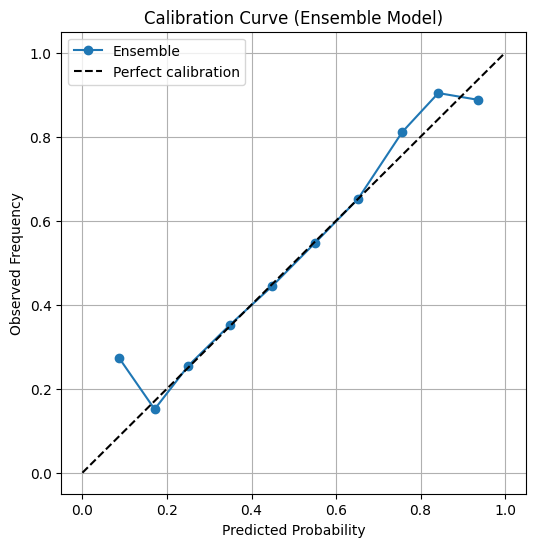

In [24]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_test_seq,
    ensemble_probs,
    n_bins=10,
    strategy="uniform"
)

# Plot reliability diagram
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Ensemble")
plt.plot([0,1], [0,1], "k--", label="Perfect calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve (Ensemble Model)")
plt.legend()
plt.grid(True)
plt.show()


It shows the relationship between predicted probabilities and observed frequencies.

## C20 — Load LSTM Model for Additional Evaluation

This cell loads the trained LSTM model for further evaluation tasks.


In [25]:
import tensorflow as tf

model_lstm = tf.keras.models.load_model(
    "/content/drive/MyDrive/AstroPredict_Final/lstm_phase1_model.keras"
)

print("LSTM model loaded for multi-horizon evaluation.")


LSTM model loaded for multi-horizon evaluation.


## C21 — Prediction Horizons Definition

This cell defines the prediction horizons and associated label columns used for evaluation.


In [26]:
HORIZONS = {
    "6h": "flare_label_6h",
    "12h": "flare_label_12h",
    "24h": "flare_label_24h"
}

LOOKBACK = 30  # already used


## C22 — Horizon Evaluation Function

This cell defines a helper function to evaluate the LSTM model for different prediction horizons.


In [27]:
def evaluate_lstm_horizon(df, label_col, model, feature_cols, lookback):
    X_seq, y_seq = build_sequences(
        df,
        feature_cols,
        label_col,
        lookback
    )

    probs = model.predict(X_seq).ravel()
    auc = roc_auc_score(y_seq, probs)

    thresholds = np.linspace(0.01, 0.99, 100)
    tss_scores = [compute_tss(y_seq, probs, t) for t in thresholds]
    best_tss = max(tss_scores)

    return auc, best_tss


## C23 — Multi-Horizon Evaluation Results

This cell evaluates the LSTM model across multiple prediction horizons and summarizes the results.


In [28]:
multi_horizon_results = []

for horizon, label_col in HORIZONS.items():
    auc, tss = evaluate_lstm_horizon(
        test_df,
        label_col,
        model_lstm,
        FEATURE_COLS,
        LOOKBACK
    )

    multi_horizon_results.append({
        "Horizon": horizon,
        "ROC_AUC": auc,
        "Best_TSS": tss
    })

    print(f"{horizon} → ROC-AUC: {auc:.3f}, Best TSS: {tss:.3f}")

multi_horizon_df = pd.DataFrame(multi_horizon_results)
multi_horizon_df


8197/8197 ━━━━━━━━━━━━━━━━━━━━ 111s 13ms/step
6h → ROC-AUC: 0.637, Best TSS: 0.368
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 111s 14ms/step
12h → ROC-AUC: 0.644, Best TSS: 0.364
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 111s 13ms/step
24h → ROC-AUC: 0.776, Best TSS: 0.423


,Horizon,ROC_AUC,Best_TSS
0,6h,0.637229,0.367737
1,12h,0.643707,0.363600
2,24h,0.775610,0.422568


#  Comprehensive Evaluation Metrics


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

def evaluate_model(y_true, y_prob, threshold=0.5):
    """
    Computes comprehensive evaluation metrics for solar flare prediction.
    """

    # Convert probabilities to binary predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Standard classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ROC-AUC (threshold-independent)
    roc_auc = roc_auc_score(y_true, y_prob)

    # Space weather skill scores
    tss = (tp / (tp + fn)) - (fp / (fp + tn))

    hss = (2 * (tp * tn - fp * fn)) / (
        (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TSS": tss,
        "HSS": hss,
        "ROC-AUC": roc_auc
    }


In [30]:
# BASELINE MODEL EVALUATION (Threshold = 0.5)

print("Evaluating XGBoost...")
metrics_xgb = evaluate_model(y_test, xgb_probs)

print("Evaluating LSTM...")
metrics_lstm = evaluate_model(y_test_seq, lstm_probs)

print("Evaluating BiLSTM...")
metrics_bilstm = evaluate_model(y_test_seq, bilstm_probs)

print("Evaluating Ensemble...")
metrics_ensemble = evaluate_model(y_test_seq, ensemble_probs)

# MASTER BASELINE RESULTS TABLE


results_df = pd.DataFrame.from_dict(
    {
        "XGBoost (Baseline)": metrics_xgb,
        "LSTM (Baseline)": metrics_lstm,
        "BiLSTM (Baseline)": metrics_bilstm,
        "Ensemble": metrics_ensemble
    },
    orient="index"
)

# Column order (matches report)
results_df = results_df[
    ["Accuracy", "Precision", "Recall", "F1", "TSS", "HSS", "ROC-AUC"]
]

print("\n=== MASTER BASELINE RESULTS ===")
print(results_df)

# Save for report & appendix
results_df.to_csv("baseline_evaluation_results.csv")
print("\n✅ Results saved to 'baseline_evaluation_results.csv'")


Evaluating XGBoost...
Evaluating LSTM...
Evaluating BiLSTM...
Evaluating Ensemble...

=== MASTER BASELINE RESULTS ===
                    Accuracy  Precision    Recall        F1       TSS  \
XGBoost (Baseline)  0.580024   0.682841  0.534839  0.599846  0.179498   
LSTM (Baseline)     0.714567   0.751892  0.768875  0.760289  0.405703   
BiLSTM (Baseline)   0.731730   0.775199  0.766635  0.770893  0.448401   
Ensemble            0.733198   0.767317  0.784792  0.775956  0.444136   

                         HSS   ROC-AUC  
XGBoost (Baseline)  0.171498  0.624490  
LSTM (Baseline)     0.407690  0.775610  
BiLSTM (Baseline)   0.447335  0.804904  
Ensemble            0.446329  0.797344  

✅ Results saved to 'baseline_evaluation_results.csv'


In [31]:
display(results_df)
results_df.to_csv("baseline_evaluation_results.csv", index=True)


,Accuracy,Precision,Recall,F1,TSS,HSS,ROC-AUC
XGBoost (Baseline),0.580024,0.682841,0.534839,0.599846,0.179498,0.171498,0.624490
LSTM (Baseline),0.714567,0.751892,0.768875,0.760289,0.405703,0.407690,0.775610
BiLSTM (Baseline),0.731730,0.775199,0.766635,0.770893,0.448401,0.447335,0.804904
Ensemble,0.733198,0.767317,0.784792,0.775956,0.444136,0.446329,0.797344



# Visualization 1: Confusion Matrices (Baseline Models)



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_prob, threshold=0.5, title="Confusion Matrix"):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Flare", "Flare"],
        yticklabels=["No Flare", "Flare"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


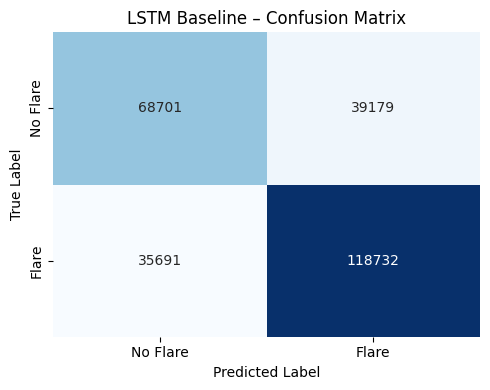

In [33]:
plot_confusion_matrix(
    y_test_seq,
    lstm_probs,
    threshold=0.5,
    title="LSTM Baseline – Confusion Matrix"
)


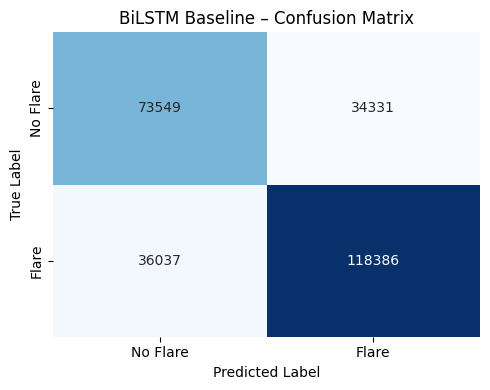

In [34]:
plot_confusion_matrix(
    y_test_seq,
    bilstm_probs,
    threshold=0.5,
    title="BiLSTM Baseline – Confusion Matrix"
)


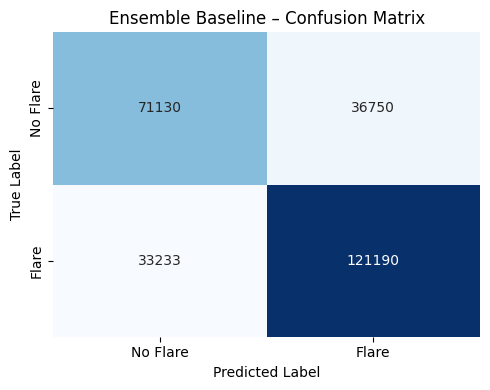

In [35]:
plot_confusion_matrix(
    y_test_seq,
    ensemble_probs,
    threshold=0.5,
    title="Ensemble Baseline – Confusion Matrix"
)



# Visualization 2: ROC Curves (Baseline Model Comparison)



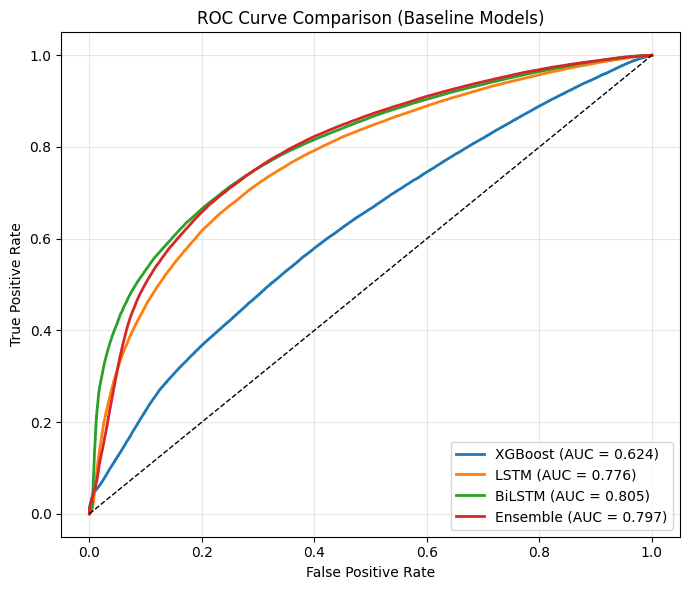

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

models = {
    "XGBoost": (y_test, xgb_probs),
    "LSTM": (y_test_seq, lstm_probs),
    "BiLSTM": (y_test_seq, bilstm_probs),
    "Ensemble": (y_test_seq, ensemble_probs)
}

for name, (y_true, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier reference
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Baseline Models)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Visualization 3: Precision–Recall Curves (Baseline Models)



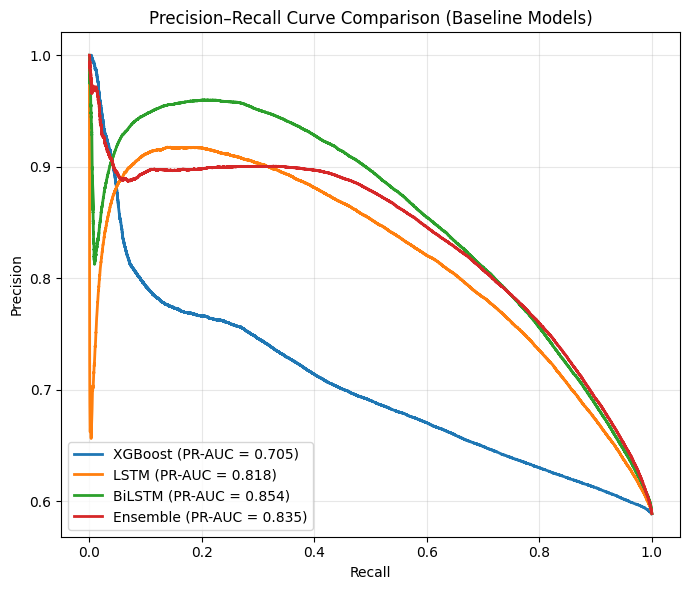

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(7, 6))

models = {
    "XGBoost": (y_test, xgb_probs),
    "LSTM": (y_test_seq, lstm_probs),
    "BiLSTM": (y_test_seq, bilstm_probs),
    "Ensemble": (y_test_seq, ensemble_probs)
}

for name, (y_true, y_prob) in models.items():
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (Baseline Models)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Visualization 4: Metrics Comparison Bar Chart



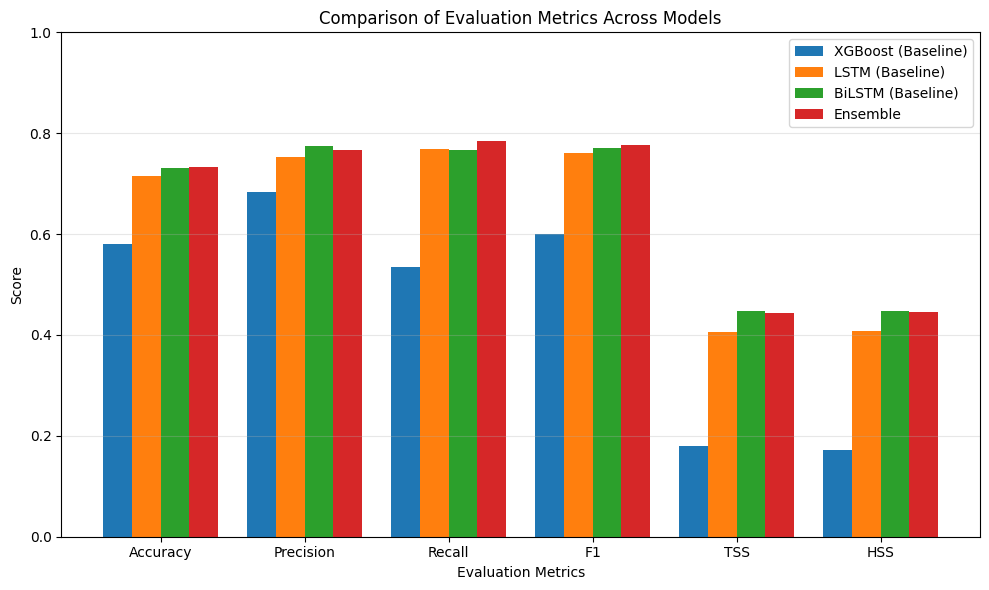

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to visualize
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "TSS", "HSS"]

# Ensure correct column names
plot_df = results_df[metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.2

plt.figure(figsize=(10, 6))

for i, model in enumerate(plot_df.index):
    plt.bar(
        x + i * width,
        plot_df.loc[model],
        width,
        label=model
    )

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Comparison of Evaluation Metrics Across Models")
plt.xticks(x + width * (len(plot_df.index) - 1) / 2, metrics_to_plot)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Visualization 5: TSS vs Decision Threshold



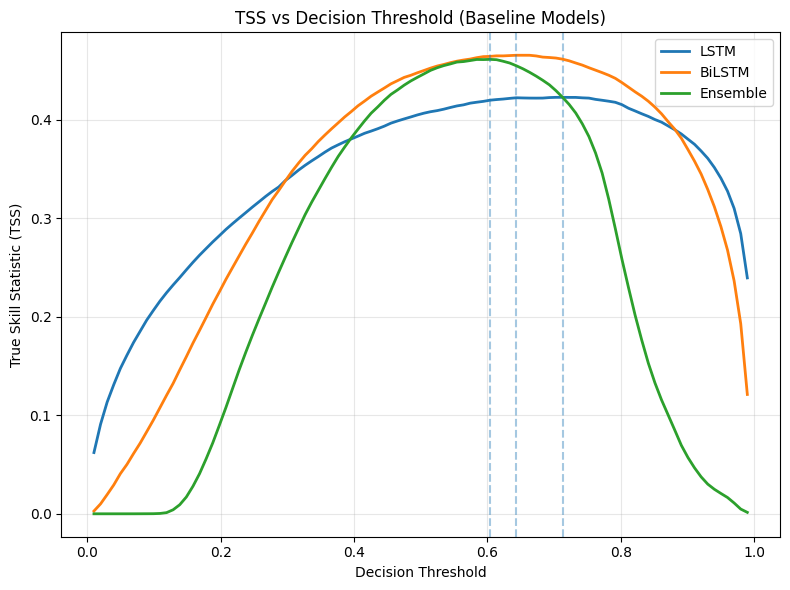

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def compute_tss(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return tpr - fpr


thresholds = np.linspace(0.01, 0.99, 100)

models = {
    "LSTM": (y_test_seq, lstm_probs),
    "BiLSTM": (y_test_seq, bilstm_probs),
    "Ensemble": (y_test_seq, ensemble_probs)
}

plt.figure(figsize=(8, 6))

for name, (y_true, y_prob) in models.items():
    tss_scores = [compute_tss(y_true, y_prob, t) for t in thresholds]
    best_idx = np.argmax(tss_scores)

    plt.plot(thresholds, tss_scores, linewidth=2, label=name)
    plt.axvline(
        thresholds[best_idx],
        linestyle="--",
        alpha=0.4
    )

plt.xlabel("Decision Threshold")
plt.ylabel("True Skill Statistic (TSS)")
plt.title("TSS vs Decision Threshold (Baseline Models)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##  Notebook Summary

This notebook evaluates the machine learning models trained in **Notebook-02** using the test dataset derived from **Notebook-01**.

The objective of this notebook is to:
- Load the trained models,
- Generate predictions on the test data,
- Compute standard evaluation metrics,
- Compare model outputs in a consistent and reproducible manner.


## What Was Evaluated

The following models were evaluated:

- **XGBoost** (tabular baseline model)
- **LSTM** (temporal sequence model)
- **BiLSTM** (bidirectional temporal model)
- **Ensemble model** (average of XGBoost, LSTM, and BiLSTM predictions)

All evaluations were performed on the same test split defined at the **HARPNUM (active region) level** to ensure consistency with training.

## Evaluation Procedures

1. **Prediction Generation**
   - Model predictions were generated on the test dataset.
   - Sequence-based models used the same lookback window and sequence construction logic as in training.

2. **Metric Computation**
   - ROC-AUC was computed for all evaluated models.
   - True Skill Statistic (TSS) was computed across a range of decision thresholds.
   - Best TSS values were recorded for comparison.

3. **Visualization**
   - ROC curves were plotted to compare model discrimination behavior.
   - TSS variation with threshold was visualized.
   - Feature importance was extracted from the XGBoost model and displayed.
   - A calibration curve was plotted for diagnostic inspection of ensemble probabilities.

4. **Multi-Horizon Evaluation**
   - The LSTM model was evaluated for multiple prediction horizons (6h, 12h, 24h).
   - ROC-AUC and best TSS values were computed for each horizon.

## Outputs of This Notebook

- ROC-AUC values for all evaluated models
- Best TSS values across thresholds
- ROC curve visualizations
- TSS vs threshold plots
- Feature importance table and visualization
- Calibration curve for ensemble predictions
- Multi-horizon evaluation results table


## Conclusion

This notebook completes the **Phase-1 evaluation stage** of AstroPredict by providing a consistent and reproducible assessment of all trained models.  
The results produced here are used for comparison, reporting, and discussion in subsequent thesis chapters.
